<a href="https://colab.research.google.com/github/zwimpee/cursivetransformer/blob/main/visualize_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone the cursivetransformer repository and install its requirements
!rm -rf cursivetransformer && git clone https://github.com/zwimpee/cursivetransformer.git
!cd cursivetransformer && pip install -r requirements.txt
!wandb login

Cloning into 'cursivetransformer'...
remote: Enumerating objects: 3066, done.
remote: Counting objects: 100% (680/680), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 3066 (delta 605), reused 620 (delta 558), pack-reused 2386 (from 1)
Receiving objects: 100% (3066/3066), 64.71 MiB | 13.82 MiB/s, done.
Resolving deltas: 100% (1719/1719), done.
  Cloning https://github.com/callummcdougall/CircuitsVis.git to /tmp/pip-req-build-t8skam_6
  Running command git clone --filter=blob:none --quiet https://github.com/callummcdougall/CircuitsVis.git /tmp/pip-req-build-t8skam_6
  Resolved https://github.com/callummcdougall/CircuitsVis.git to commit 1e6129d08cae7af9242d9ab5d3ed322dd44b4dd3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which 

In [2]:
import sys
sys.path.append('/content/cursivetransformer/')

import numpy as np
import torch
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from cursivetransformer.model import get_all_args, get_checkpoint
from cursivetransformer.data import create_datasets
from cursivetransformer.sample import generate_n_words, plot_strokes, offsets_to_strokes

In [3]:
args = get_all_args(False)
args.wandb_project = 'bigbank_2k'
args.load_from_run_id = '7e9hz1og'
args.max_seq_length = 1250
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
train_dataset, test_dataset = create_datasets(args)
args.block_size = train_dataset.get_stroke_seq_length()
args.context_block_size = train_dataset.get_text_seq_length()
args.vocab_size = train_dataset.get_vocab_size()
args.context_vocab_size = train_dataset.get_char_vocab_size()
print(f"Dataset determined that: {args.vocab_size=}, {args.block_size=}")
model, _, _, _, _ = get_checkpoint(args, sample_only=True)

Enter your W&B API key: ··········
Trying to load dataset file from /content/cursivetransformer/data/bigbank.json.zip
Succeeded in loading the bigbank dataset; contains 2000 items.
For a dataset of 1900 examples we can generate 205257574037880 combinations of 5 examples.
Generating 497000 random combinations.
For a dataset of 100 examples we can generate 75287520 combinations of 5 examples.
Generating 3000 random combinations.
Number of examples in the train dataset: 497000
Number of examples in the test dataset: 3000
Max token sequence length: 1250
Number of unique characters in the ascii vocabulary: 71
Ascii vocabulary:
	" enaitoshrdx.vpukbgfcymzw1lqj804I92637OTAS5N)EHR"'(BCQLMWYU,ZF!DXV?KPGJ"
Split up the dataset into 497000 training examples and 3000 test examples
Dataset determined that: args.vocab_size=382, args.block_size=1250
Number of Transformer parameters: 379392
Model #params: 403840
Finding latest checkpoint for W&B run id 7e9hz1og
  model:best_checkpoint:v129
  model:best

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb:   1 of 1 files downloaded.  


In [4]:
x, c, y = test_dataset[0]
x = x.unsqueeze(0).to('cuda')
c = c.unsqueeze(0).to('cuda')
y = y.unsqueeze(0).to('cuda')

In [5]:
self_attn_patterns = {i: {} for i in range(len(model.transformer.h))}
cross_attn_patterns = {i: {} for i in range(len(model.transformer.h))}

def self_attn_hook(mod, inp, out):
    # The attention pattern is computed but not directly returned
    # We need to recompute it here
    q, k, v = mod.c_attn(inp[0]).split(mod.n_embd, dim=2)
    B, T, C = q.size()
    k = k.view(B, T, mod.n_head, C // mod.n_head).transpose(1, 2)
    q = q.view(B, T, mod.n_head, C // mod.n_head).transpose(1, 2)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(mod.bias[:,:,:T,:T] == 0, float('-inf'))
    att = F.softmax(att, dim=-1)
    layer_idx = next(i for i, layer in enumerate(model.transformer.h) if layer.attn == mod)
    self_attn_patterns[layer_idx][mod] = att.detach()

def cross_attn_hook(mod, inp, out):
    # The attention pattern is computed but not directly returned
    # We need to recompute it here
    x, context = inp
    B, T, C = x.size()
    _, T_ctx, _ = context.size()
    q = mod.c_attn_q(x).view(B, T, mod.n_ctx_head, C // mod.n_ctx_head).transpose(1, 2)
    k, v = mod.c_attn_kv(context).split(mod.n_embd_context, dim=2)
    k = k.view(B, T_ctx, mod.n_ctx_head, C // mod.n_ctx_head).transpose(1, 2)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = F.softmax(att, dim=-1)
    layer_idx = next(i for i, layer in enumerate(model.transformer.h) if layer.cross_attn == mod)
    cross_attn_patterns[layer_idx][mod] = att.detach()

for layer in model.transformer.h:
    layer.attn.register_forward_hook(self_attn_hook)
    layer.cross_attn.register_forward_hook(cross_attn_hook)

Self-attention pattern shape: torch.Size([1, 4, 1250, 1250])
Cross-attention pattern shape: torch.Size([1, 4, 1250, 50])


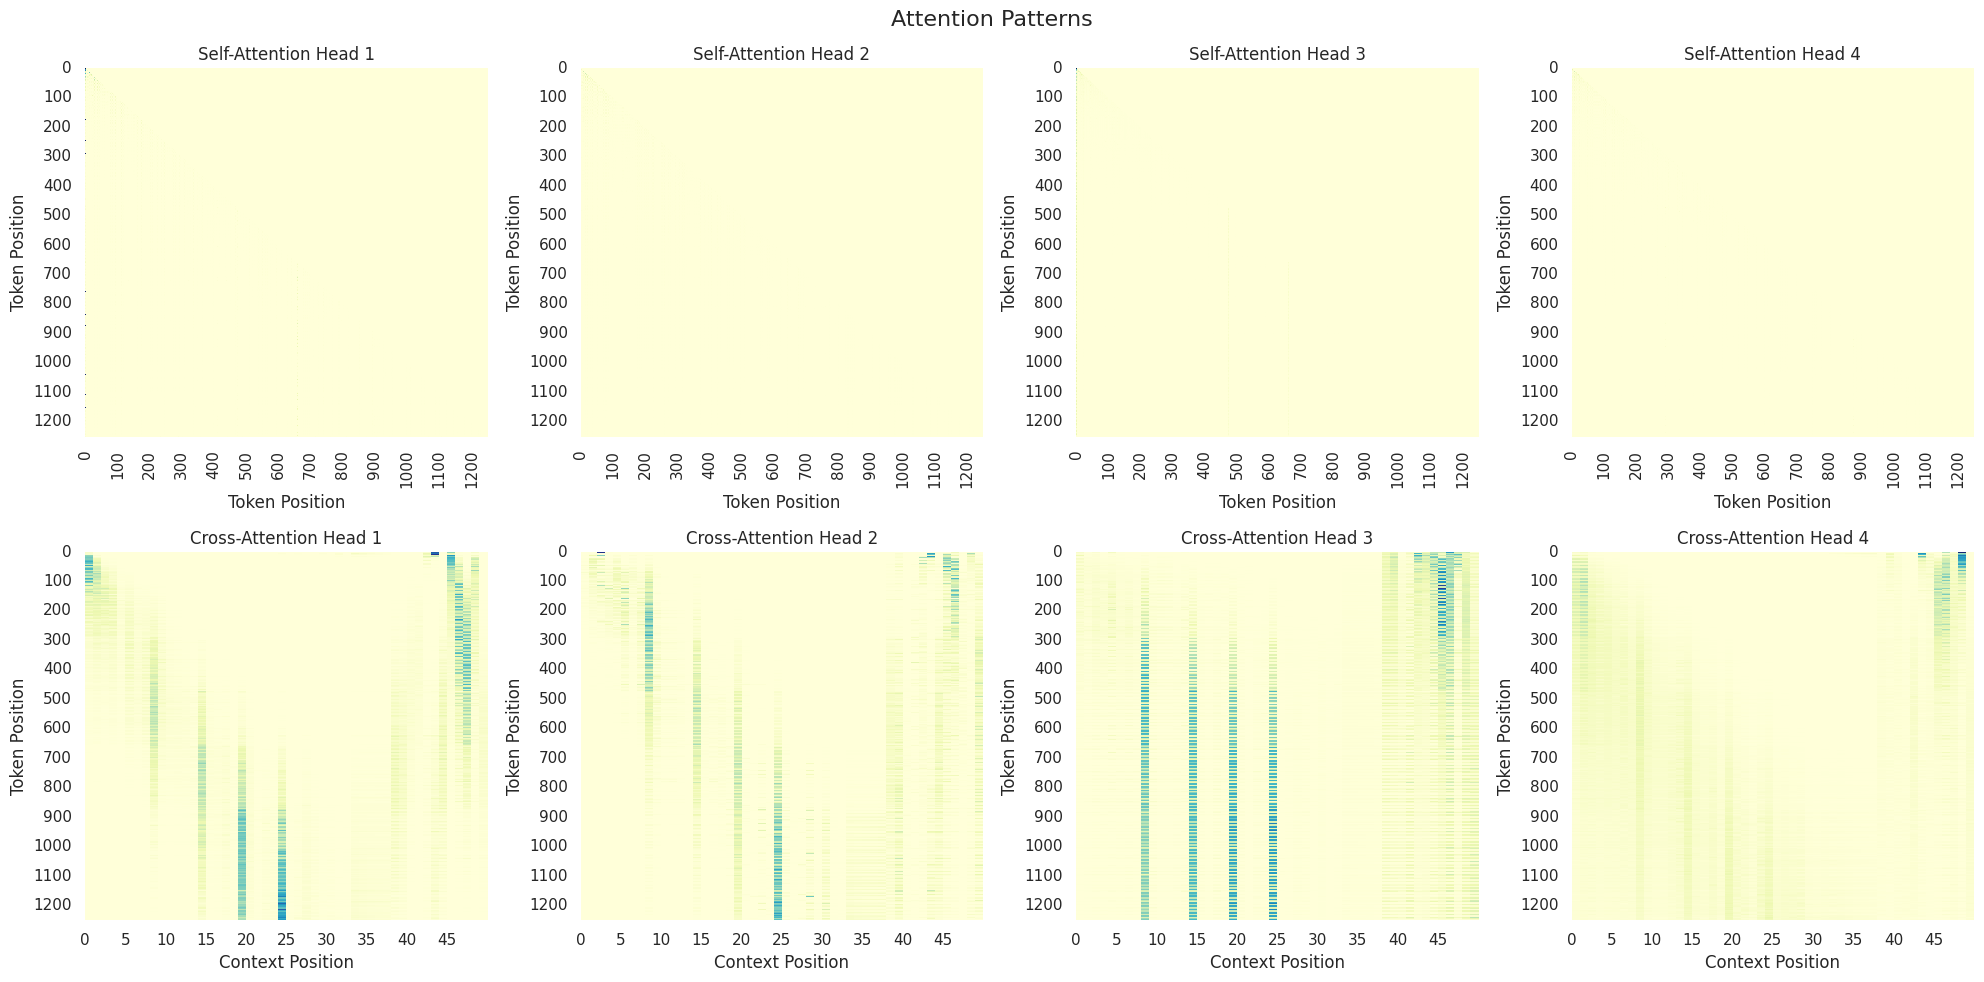

In [16]:
def visualize_attention_patterns(self_attn_patterns, cross_attn_patterns, num_heads_to_plot=4,  layer_idx=0):
    # Get the first (and only) item from each dictionary
    self_attn = next(iter(self_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()
    cross_attn = next(iter(cross_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()


    # Get dimensions
    num_heads = self_attn.shape[0]
    seq_len = self_attn.shape[1]
    context_len = cross_attn.shape[2]

    # Set up the plot
    fig, axes = plt.subplots(2, num_heads_to_plot, figsize=(20, 10))
    fig.suptitle("Attention Patterns", fontsize=16)

    # Plot self-attention patterns
    for i in range(num_heads_to_plot):
        sns.heatmap(self_attn[i], ax=axes[0, i], cmap="YlGnBu", cbar=False)
        axes[0, i].set_title(f"Self-Attention Head {i+1}")
        axes[0, i].set_xlabel("Token Position")
        axes[0, i].set_ylabel("Token Position")

        # Set x and y ticks to show only every 100th position
        tick_locations = np.arange(0, seq_len, 100)
        axes[0, i].set_xticks(tick_locations)
        axes[0, i].set_yticks(tick_locations)
        axes[0, i].set_xticklabels(tick_locations)
        axes[0, i].set_yticklabels(tick_locations)

    # Plot cross-attention patterns
    for i in range(num_heads_to_plot):
        sns.heatmap(cross_attn[i], ax=axes[1, i], cmap="YlGnBu", cbar=False)
        axes[1, i].set_title(f"Cross-Attention Head {i+1}")
        axes[1, i].set_xlabel("Context Position")
        axes[1, i].set_ylabel("Token Position")

        # Set x ticks to show only every 5th position for context
        x_tick_locations = np.arange(0, context_len, 5)
        axes[1, i].set_xticks(x_tick_locations)
        axes[1, i].set_xticklabels(x_tick_locations)

        # Set y ticks to show only every 100th position for tokens
        y_tick_locations = np.arange(0, seq_len, 100)
        axes[1, i].set_yticks(y_tick_locations)
        axes[1, i].set_yticklabels(y_tick_locations)

    plt.tight_layout()
    plt.show()

# Call the function to visualize attention patterns
# visualize_attention_patterns(self_attn_patterns, cross_attn_patterns)

In [ ]:
def visualize_strokes_and_attention(stroke, title, self_attn, cross_attn):
    fig, (ax_stroke, ax_self, ax_cross) = plt.subplots(3, 1, figsize=(12, 10), dpi=150, gridspec_kw={'height_ratios': [2, 1, 1]})

    # Plot strokes
    strokes = []
    current_stroke = []
    for point in stroke:
        if point[2] == 1:  # Pen is down
            current_stroke.append(point)
        else:  # Pen is up
            if current_stroke:
                strokes.append(current_stroke)
                current_stroke = []
    if current_stroke:
        strokes.append(current_stroke)

    for stroke in strokes:
        x, y = zip(*[(p[0], 1 - p[1]) for p in stroke])  # Invert y-axis
        ax_stroke.plot(x, y, 'b-', linewidth=1.3)

    ax_stroke.set_aspect('equal')
    ax_stroke.set_title(title)

    # Plot self-attention
    im_self = ax_self.imshow(self_attn, aspect='auto', cmap='YlGnBu')
    ax_self.set_title("Self-Attention (Average across heads)")
    ax_self.set_xlabel("Token Position")
    ax_self.set_ylabel("Token Position")
    plt.colorbar(im_self, ax=ax_self)

    # Plot cross-attention
    im_cross = ax_cross.imshow(cross_attn, aspect='auto', cmap='YlGnBu')
    ax_cross.set_title("Cross-Attention (Average across heads)")
    ax_cross.set_xlabel("Context Position")
    ax_cross.set_ylabel("Token Position")
    plt.colorbar(im_cross, ax=ax_cross)

    plt.tight_layout()
    plt.show()

def process_multiple_examples(model, dataset, num_examples=5):
    for i in range(num_examples):
        x, c, y = dataset[i]
        x = x.unsqueeze(0).to('cuda')
        c = c.unsqueeze(0).to('cuda')
        y = y.unsqueeze(0).to('cuda')

        with torch.no_grad():
            output = model(x, c)

        # Visualize attention patterns for each layer
        for layer_idx in range(len(model.transformer.h)):
            self_attn = next(iter(self_attn_patterns[layer_idx].values())).squeeze(0).mean(0).cpu().numpy()
            cross_attn = next(iter(cross_attn_patterns[layer_idx].values())).squeeze(0).mean(0).cpu().numpy()

            strokes = offsets_to_strokes(x.squeeze().cpu().numpy())
            visualize_strokes_and_attention(strokes, f"Example {i+1}, Layer {layer_idx+1}", self_attn, cross_attn)

# Call the function to process multiple examples
process_multiple_examples(model, test_dataset)